## Упражнение 4.1

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

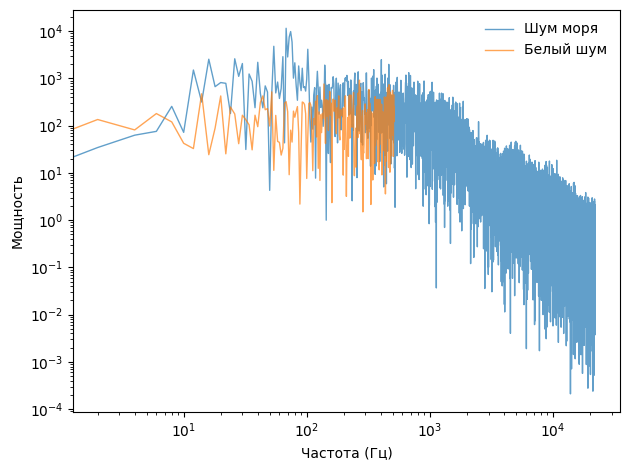

In [15]:
from thinkdsp import *

signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5, framerate=1024)
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
label = 'Белый шум'

loglog = dict(xscale='log', yscale='log')

wave = read_wave("north-sea.wav")
sea_wave = wave.segment(start=1, duration=0.5)
sea_spectrum = sea_wave.make_spectrum()
sea_spectrum.hs[0] = 0

sea_spectrum.plot_power(linewidth=1, alpha=0.7, label='Шум моря')
spectrum.plot_power(linewidth=1, alpha=0.7, label=label)
    
decorate(xlabel='Частота (Гц)',
         ylabel='Мощность',
         **loglog)

Больше похоже на белый шум.

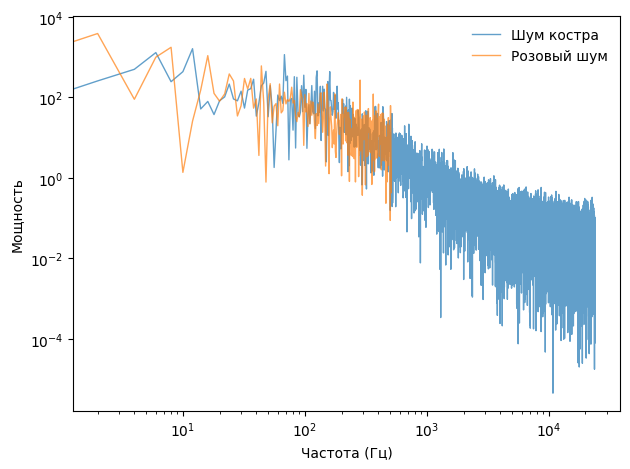

In [18]:
signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5, framerate=1024)
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
label = 'Розовый шум'

wave = read_wave("fireplace.wav")
fire_wave = wave.segment(start=1, duration=0.5)
fire_spectrum = fire_wave.make_spectrum()
fire_spectrum.hs[0] = 0

fire_spectrum.plot_power(linewidth=1, alpha=0.7, label='Шум костра')
spectrum.plot_power(linewidth=1, alpha=0.7, label=label)
    
decorate(xlabel='Частота (Гц)',
         ylabel='Мощность',
         **loglog)

Больше похож на розовый шум.

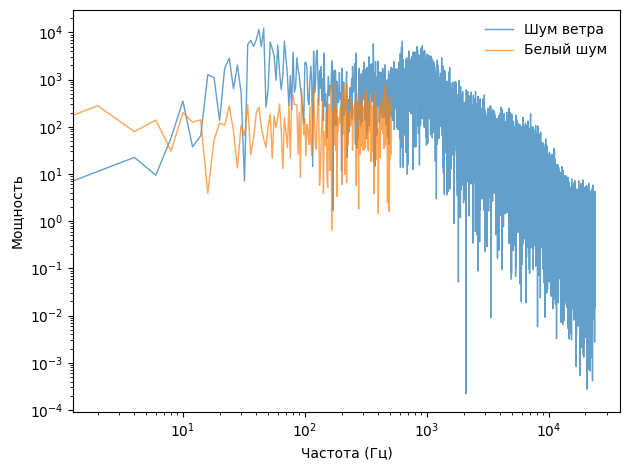

In [23]:
signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5, framerate=1024)
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
label = 'Белый шум'

wave = read_wave("strong-wind.wav")
wind_wave = wave.segment(start=1, duration=0.5)
wind_spectrum = wind_wave.make_spectrum()
wind_spectrum.hs[0] = 0

wind_spectrum.plot_power(linewidth=1, alpha=0.7, label='Шум ветра')
spectrum.plot_power(linewidth=1, alpha=0.7, label=label)
    
decorate(xlabel='Частота (Гц)',
         ylabel='Мощность',
         **loglog)

Больше похож на белый шум.

Для естественных звуков преобладают больше белые и розовые шумы как менее коррелированные, чем красные. Для всех wav-отрывков свойственен спад мощности при повышении частоты.

## Упражнение 4.2

In [28]:
def bartlett(wave, seg_length=512, win_flag=True):
    
    spectrums = wave.make_spectrogram(seg_length, win_flag).spec_map.values()
    psds = [spectrum.power for spectrum in spectrums]
    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs
    spectrum = Spectrum(hs, fs, wave.framerate)
    
    return spectrum

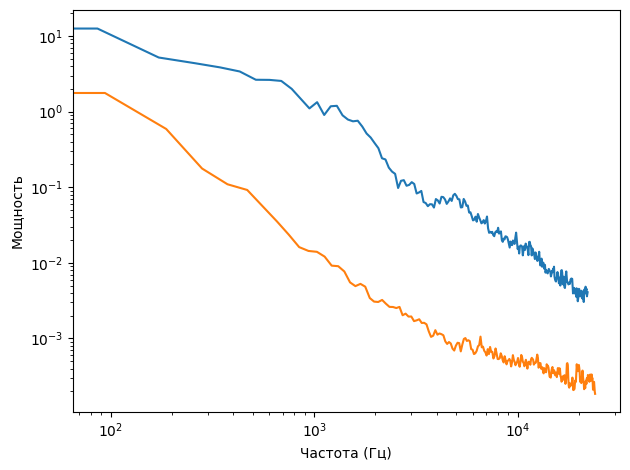

In [30]:
br1 = bartlett(sea_wave)
br2 = bartlett(fire_wave)

br1.plot_power()
br2.plot_power()

decorate(xlabel='Частота (Гц)', 
         ylabel='Мощность', 
         **loglog)

## Упражнение 4.3

На сайте www.coindesk.com не было найдено функции загрузки истории курса в формате CSV, поэтому было решено использовать библиотеку yfinance. Получим csv данные.

In [53]:
import yfinance as yf
import pandas as pd

ticker = "BTC-USD"
data = yf.download(ticker, start="2024-05-20", end="2026-05-20")

data.to_csv('bitcoin_prices_yfinance.csv')
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990
2024-05-22,69122.335938,70623.695312,68977.695312,70135.320312,32802561717
2024-05-23,67929.562500,70041.273438,66356.953125,69121.304688,41895680979
2024-05-24,68526.101562,69220.296875,66622.671875,67928.132812,29197308153
...,...,...,...,...,...
2026-05-15,79065.679688,81634.843750,78635.367188,81046.867188,38183347368
2026-05-16,78131.437500,79173.500000,77630.734375,79066.000000,25895799905


In [54]:
ys = data['Close'].values.flatten()
ts = np.arange(1, len(data) + 1)

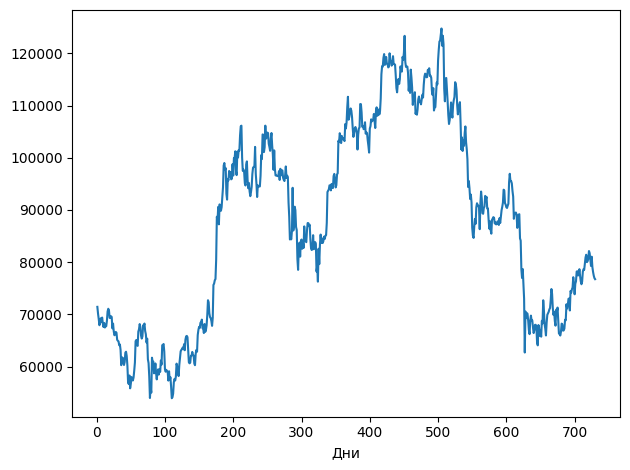

In [58]:
bitcoin_wave = Wave(ys, ts, framerate=1)
bitcoin_wave.plot()
decorate(xlabel='Дни')

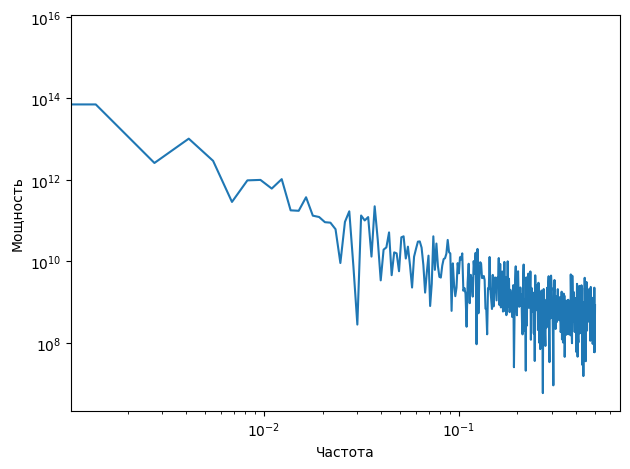

In [63]:
bitcoin_spectrum = bitcoin_wave.make_spectrum()
bitcoin_spectrum.plot_power()

decorate(xlabel='Частота',
         ylabel='Мощность', 
         **loglog)

In [64]:
bitcoin_spectrum.estimate_slope()[0]

np.float64(-1.7964284818300769)

По идее, данные должны быть коррелированы, и шум должен быть похож на красный. Тем не менее, мы получили угол наклона примерно 1.8, что говорит о розовом шуме.

## Упражнение 4.4

In [66]:
class UncorrelatedPoissonNoise(Noise):
    
    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys

In [77]:
dur = 1
fr = 10000

# Создадим сигнал шума с малой амплитудой (должен походить на звук счётчика Гейгера)
signal1 = UncorrelatedPoissonNoise(amp=0.001)
wave1 = signal1.make_wave(duration=dur, framerate=fr)
wave1.make_audio()

In [74]:
# Создадим сигнал шума с большой амплитудой (должен походить на белый шум)
signal2 = UncorrelatedPoissonNoise(amp=1)
wave2 = signal2.make_wave(duration=dur, framerate=fr)
wave2.make_audio()

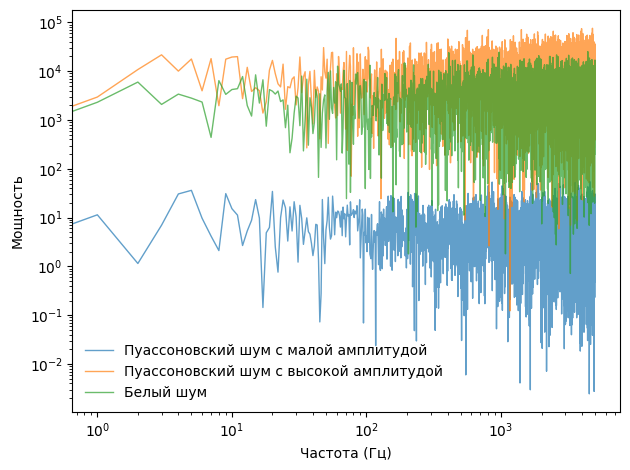

In [75]:
signal3 = PinkNoise(beta=0)
wave3 = signal3.make_wave(duration=dur, framerate=fr)
spectrum3 = wave3.make_spectrum()
spectrum3.hs[0] = 0
label3 = 'Белый шум'

spectrum2 = wave2.make_spectrum()
spectrum2.hs[0] = 0
label2 = 'Пуассоновский шум с высокой амплитудой'

spectrum1 = wave1.make_spectrum()
spectrum1.hs[0] = 0
label1 = 'Пуассоновский шум с малой амплитудой'

spectrum1.plot_power(linewidth=1, alpha=0.7, label=label1)
spectrum2.plot_power(linewidth=1, alpha=0.7, label=label2)
spectrum3.plot_power(linewidth=1, alpha=0.7, label=label3)
    
decorate(xlabel='Частота (Гц)',
         ylabel='Мощность',
         **loglog)

Действительно, при амплитуде около 1 пуассоновский шум начинает походить на белый, однако при чрезмерном увеличении амплитуды пуассоновский шут также отклониться от белого.

## Упражнение 4.5

In [82]:
class CustomPinkNoiseWave(Wave):

    def __init__(self, nrows, ncols=16):
        array = np.empty((nrows, ncols))
        array.fill(np.nan)
        array[0, :] = np.random.random(ncols)
        array[:, 0] = np.random.random(nrows)
    
        n = nrows
        cols = np.random.geometric(0.5, n)
        cols[cols >= ncols] = 0
        rows = np.random.randint(nrows, size=n)
        array[rows, cols] = np.random.random(n)

        df = pd.DataFrame(array)
        df.ffill(axis=0, inplace=True)
        ys = df.sum(axis=1)

        super().__init__(ys)

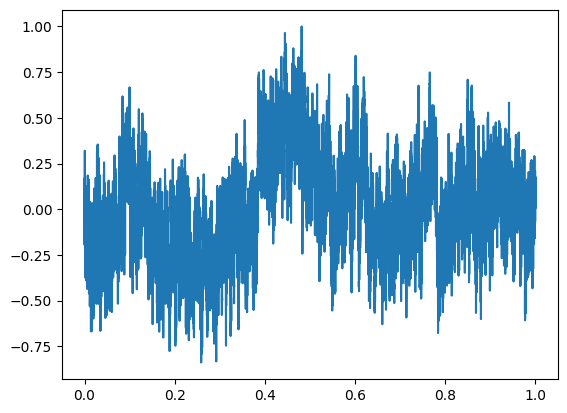

In [83]:
wave = CustomPinkNoiseWave(11025)
wave.unbias()
wave.normalize()
wave.plot()

Сигнал, как и в случае с Броуновским шумом, блуждает вверх и вниз, однако выглядит более случайным (больший разброс значений по вертикали).

Изобразим спектр полученного шума и найдём угол наклона.

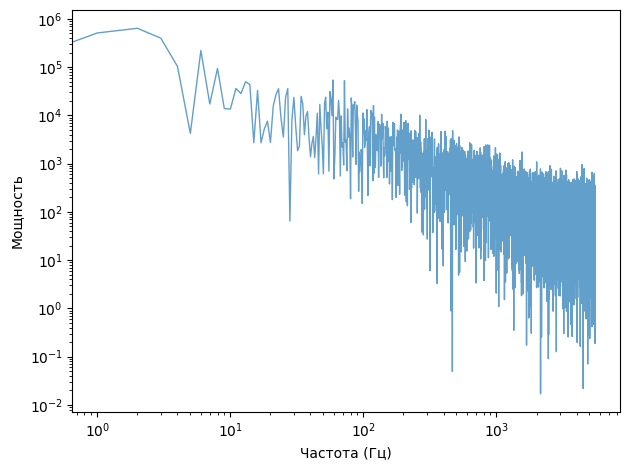

In [85]:
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
spectrum.plot_power(linewidth=1, alpha=0.7)
    
decorate(xlabel='Частота (Гц)',
         ylabel='Мощность',
         **loglog)

In [86]:
spectrum.estimate_slope()[0]

np.float64(-0.9963949167986864)

Угол наклона ближе к 1, что соответствует розовому шуму.